# Setup

In [1]:
# Setup
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import requests
from io import BytesIO

# Segmentação de imagens

A segmentação de imagens é uma técnica de processamento de imagens que divide uma imagem em várias partes ou segmentos, tornando a análise de objetos e regiões de interesse mais fácil. O objetivo principal é simplificar a representação da imagem e torná-la mais significativa para análise ou tomada de decisão. Neste notebook, você poderá estudar acerca de diversas técnicas que são utilizadas em segmentação, bem como ver na prática (em código) como elas funcionam.






## Thresholding

Thresholding é um processo de conversão de uma imagem em escala de cinza para uma imagem binária, em que os pixels são representados por apenas dois valores: 0 ou 255.

### Thresholding simples

A aplicação de métodos de thresholding simples exige a intervenção humana, pois é necessário determinar um valor de limiar, representado por T. Nesse processo, todas as intensidades de pixel inferiores a T são atribuídas o valor 0, enquanto as intensidades superiores a T recebem o valor 255.

Além disso, é possível reverter esse processo de binarização, onde os pixels abaixo de T são definidos como 255, e os pixels com intensidades superiores a T são definidos como 0. Essa abordagem pode ser útil em cenários onde o foco está nas áreas de maior intensidade.

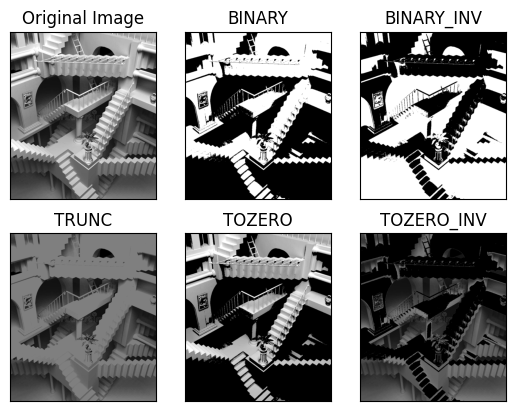

In [2]:
# URL da imagem a ser processada
url = "https://drive.google.com/uc?export=view&id=1L-xl41SqM_X90ZOHxxJ06OM_qk5IBI4X"

# Fazendo uma requisição HTTP para obter a imagem
response = requests.get(url)

# Convertendo o conteúdo da resposta em um array de bytes e depois em um array NumPy
img_array = np.array(bytearray(response.content), dtype=np.uint8)

# Decodificando a imagem para o formato original
img = cv.imdecode(img_array, -1)

# Convertendo a imagem para escala de cinza
img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Verificando se a imagem foi carregada corretamente
assert img is not None, "file could not be read, check with os.path.exists()"

# Aplicando diferentes tipos de thresholding na imagem
# 1. Threshold binário: Pixels acima do limiar (127) recebem o valor máximo (255), os demais recebem 0.
ret, thresh1 = cv.threshold(img, 127, 255, cv.THRESH_BINARY)

# 2. Threshold binário invertido: Pixels acima do limiar (127) recebem 0, os demais recebem o valor máximo (255).
ret, thresh2 = cv.threshold(img, 127, 255, cv.THRESH_BINARY_INV)

# 3. Threshold truncado: Pixels acima do limiar (127) são truncados para o valor do limiar (127), os demais permanecem inalterados.
ret, thresh3 = cv.threshold(img, 127, 255, cv.THRESH_TRUNC)

# 4. Threshold para zero: Pixels acima do limiar (127) permanecem inalterados, os demais são definidos como 0.
ret, thresh4 = cv.threshold(img, 127, 255, cv.THRESH_TOZERO)

# 5. Threshold para zero invertido: Pixels acima do limiar (127) são definidos como 0, os demais permanecem inalterados.
ret, thresh5 = cv.threshold(img, 127, 255, cv.THRESH_TOZERO_INV)

# Títulos para cada tipo de imagem
titles = ['Original Image', 'BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']

# Lista contendo a imagem original e as imagens com thresholding aplicado
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

# Exibindo as imagens em um grid 2x3
for i in range(6):
    plt.subplot(2, 3, i + 1)  # Criando subplots (2 linhas, 3 colunas)
    plt.imshow(images[i], 'gray', vmin=0, vmax=255)  # Exibindo a imagem em escala de cinza
    plt.title(titles[i])  # Adicionando o título correspondente
    plt.xticks([]), plt.yticks([])  # Removendo os eixos

# Mostrando o grid de imagens
plt.show()

### Thresholding Adaptativo

De maneira simplificada, utilizar apenas um único valor de T pode não ser o mais adequado. Para contornar essa limitação, podemos utilizar o thresholding adaptativo, que analisa pequenas áreas ao redor de cada pixel e determina um valor de threshold ideal T para cada região. Esse método é eficaz quando as intensidades de pixels variam bastante e o valor de T necessário para segmentação pode ser diferente em várias partes da imagem.

Em resumo, o thresholding adaptativo ajusta o valor do limiar de forma dinâmica, considerando o contexto local de cada pixel. Essa abordagem é particularmente útil quando a imagem possui variações expressivas nas intensidades de pixels e um único valor de limiar não consegue segmentar adequadamente as áreas de interesse.

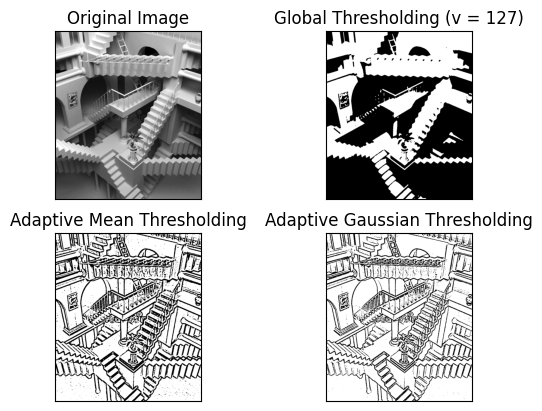

In [3]:
# Aplicando um filtro de mediana para reduzir o ruído na imagem
img = cv.medianBlur(img, 5)

# Aplicando thresholding global com um valor fixo (127)
# Pixels com valor acima de 127 serão definidos como 255, os demais como 0
ret, th1 = cv.threshold(img, 127, 255, cv.THRESH_BINARY)

# Aplicando thresholding adaptativo com a média dos vizinhos
# Cada pixel é comparado com a média dos valores de seus vizinhos em uma janela de tamanho 11x11
# O valor 2 é subtraído da média para determinar o limiar
th2 = cv.adaptiveThreshold(img, 255, cv.ADAPTIVE_THRESH_MEAN_C,
                           cv.THRESH_BINARY, 11, 2)

# Aplicando thresholding adaptativo com uma ponderação Gaussiana dos vizinhos
# Similar ao método anterior, mas os vizinhos são ponderados com base em uma distribuição Gaussiana
th3 = cv.adaptiveThreshold(img, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C,
                           cv.THRESH_BINARY, 11, 2)

# Definindo os títulos para cada imagem que será exibida
titles = ['Original Image', 'Global Thresholding (v = 127)',
          'Adaptive Mean Thresholding', 'Adaptive Gaussian Thresholding']

# Criando uma lista com as imagens para exibição
images = [img, th1, th2, th3]

# Exibindo as imagens em um grid 2x2
for i in range(4):
    plt.subplot(2, 2, i + 1)  # Criando subplots (2 linhas, 2 colunas)
    plt.imshow(images[i], 'gray')  # Exibindo a imagem em escala de cinza
    plt.title(titles[i])  # Adicionando o título correspondente
    plt.xticks([]), plt.yticks([])  # Removendo os eixos

# Mostrando o grid de imagens
plt.show()

### ❗ Atividade - Thresholding

O exercício que você vai realizar agora envolve o pré-processamento de uma imagem que retrata um processo biológico fundamental no reino animal: a mitose.

Imagine que queremos desenvolver um modelo capaz de identificar em qual fase do processo de divisão celular a célula se encontra. Com base na sua experiência em desenvolvimento de modelos, sabemos que imagens em preto e branco tendem a ser melhor classificadas. Assim, para a imagem abaixo, aplique o método de thresholding de sua preferência e avalie se, após o processamento, as fases da divisão celular se tornam mais evidentes, eliminando informações desnecessárias para o treinamento do modelo. Vale ressaltar, que em uma só imagem, há várias células, portanto o seu modelo não seria de classificar a imagem inteira, e sim de detectar diferentes objetos (fases da divisão celular).

![image.png](https://drive.google.com/uc?export=view&id=1T4X62VKPlINnOMSYeqO6Yx05dCYqCei9)

O link da imagem é: https://drive.google.com/uc?export=view&id=1T4X62VKPlINnOMSYeqO6Yx05dCYqCei9

In [4]:
# Coloque seu código aqui!

# Detecção e descritores


## Detecção de bordas

O que vem normalmente em nossa cabeça quando ouvimos a palavra borda é um lugar que delimita os objetos. Para o nosso contexto, queremos primeira detectar as bordas utilizando certos algoritmos para posteriormente delimitarmos o objeto.

A primeira coisa que pensamos ao definir uma borda é uma transição abrupta de cores, indicando que há uma linha ou região delimitadora entre duas cores, por exemplo:

![image.png](https://drive.google.com/uc?export=view&id=183KdW4fkJPZ-2fcHBiYLRrixQUgavGdv)

Acima, vemos que claramente há uma transição entre o preto e o branco, possivelmente com uma semi reta que divide essas cores no meio da imagem. Se ainda estiver confuso, observe a seguinte imagem:

![image.png](https://drive.google.com/uc?export=view&id=1GjGCXi7Mwy-_nP-coGlOo3ZSPKUgDxKX)

Se não houver uma transição abrupta, é possível definir uma borda? A resposta é não, pois há uma continuidade entre as cores dos pixels na imagem.

Ao falar em transições abruptas e mudanças de cor, imediatamente associamos esse conceito à derivada em cálculo, no caso de uma variável, ou ao gradiente, que representa o vetor de derivadas em um espaço vetorial. Mas por quê? Essencialmente, as derivadas analisam a taxa de variação de uma função. Assim, em uma imagem, uma mudança brusca de cor corresponde a uma grande diferença na magnitude dos valores dos pixels, caracterizando a presença de uma borda. Para exemplificar, observe a função que determina a intensidade em uma imagem unidimensional e sua respectiva derivada a seguir:

<img src="https://drive.google.com/uc?export=view&id=1JbWHM5eEYY2HIOPRS1RN-TwwBX6k0EQV" alt="Image" width="400" style="height: auto;">


No centro da imagem, destacado pelo círculo vermelho, observa-se a maior taxa de variação (derivada), indicando uma possível transição abrupta de cores, característica de uma borda. Assim, no nosso contexto, o gradiente deve ser calculado para cada pixel, permitindo identificar, em módulo, as regiões com os maiores valores de derivadas nas direções x e y em uma matriz bidimensional.

### Detecção de bordas - Sobel


Para resolver esse problema, Sobel propôs uma operação que aproxima o cálculo das derivadas em um determinado pixel:  
O algoritmo utiliza duas máscaras de convolução $3 \times 3 $:

$$
G_x =
\begin{bmatrix}
-1 & 0 & 1 \\
-2 & 0 & 2 \\
-1 & 0 & 1
\end{bmatrix}
$$

$$
G_y =
\begin{bmatrix}
-1 & -2 & -1 \\
0 & 0 & 0 \\
1 & 2 & 1
\end{bmatrix}
$$

Cada pixel da imagem é convoluído com essas máscaras para calcular a intensidade do gradiente nas direções horizontal $G_x$ e vertical $G_y$.

Portanto, dado um trecho da imagem representado por uma matriz $3 \times 3$ (apenas um exemplo, pode ser maior do que isso):

$$
I =
\begin{bmatrix}
A & B & C \\
D & E & F \\
G & H & I
\end{bmatrix}
$$

A aplicação do filtro $G_x$ consiste na multiplicação elemento a elemento seguida da soma, o que basicamente é a convolução espacial em vetores bidimensionais:

$$
G_x' = (-1 \cdot A) + (0 \cdot B) + (1 \cdot C) +
       (-2 \cdot D) + (0 \cdot E) + (2 \cdot F) +
       (-1 \cdot G) + (0 \cdot H) + (1 \cdot I)
$$

De forma similar, o filtro $G_y$ é aplicado como:

$$
G_y' = (-1 \cdot A) + (-2 \cdot B) + (-1 \cdot C) +
       (0 \cdot D) + (0 \cdot E) + (0 \cdot F) +
       (1 \cdot G) + (2 \cdot H) + (1 \cdot I)
$$

A magnitude do gradiente é dada pela **distância euclidiana** entre $G_x'$ e $G_y'$:

$$
G = \sqrt{G_x'^2 + G_y'^2}
$$

Essa fórmula mede a intensidade da variação da imagem e indica regiões onde há transições abruptas de cor (bordas). Quanto maior $G$, maior a chance de haver uma borda no pixel analisado. Como a matriz da imagem é 3 x 3 e o kernel também é, a convolução será uma matriz 1 x 1, a qual mostrará o resultado de uma possível borda na região central da imagem I.

Isso é um pouco confuso, portanto veja abaixo um exemplo de uma imagem que está sendo percorrida pelos kernels 3 x 3 (horizontal e vertical) de Sobel:




![image.gif](https://drive.google.com/uc?export=view&id=1xQ0luhs1baFwZqqFqLaP7MJdol6QGYp-)

Vamos ver esse algoritmo funcionando na prática:

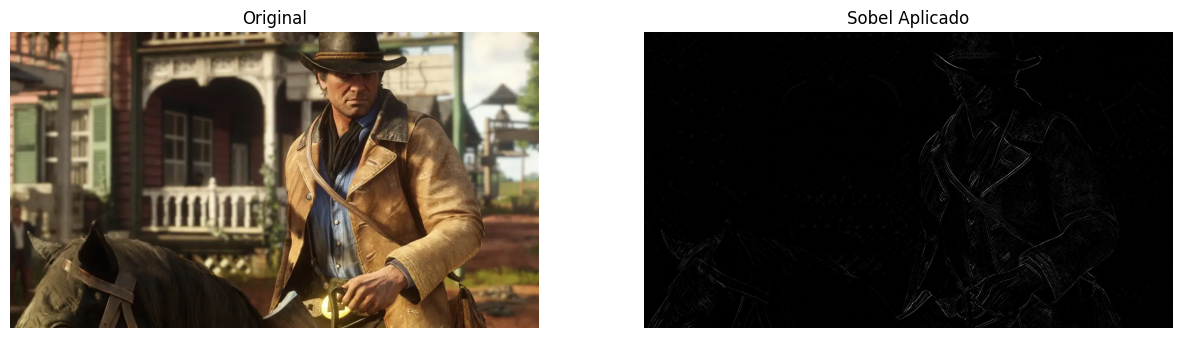

In [5]:
# Endereço da imagem na internet para você não se preocupar com importar cada imagem no colab
url = "https://drive.google.com/uc?export=view&id=1vy0RRkIxFVxgdcet7cCLkBjGp0t-XSHu"

# Baixando a imagem da URL
response = requests.get(url)
img_array = np.array(bytearray(response.content), dtype=np.uint8)
img = cv.imdecode(img_array, -1)  # -1 para carregar a imagem no formato original

# Convertendo a imagem de BGR para RGB
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Aplicando o filtro Sobel
sobel = cv.Sobel(img_rgb, -1, 1, 1)

# Exibindo a imagem original e o resultado do Sobel
fig, ax = plt.subplots(ncols=2, figsize=(15, 5))
ax[0].imshow(img_rgb)  # Usando a imagem RGB
ax[0].set_title('Original')
ax[0].axis('off')
ax[1].imshow(sobel, cmap='gray')
ax[1].set_title('Sobel Aplicado')
ax[1].axis('off')
plt.show()

### Detecção de bordas - Canny

A **Detecção de Bordas Canny** envolve múltiplas etapas para refinar a detecção de bordas, utilizando um **filtro Gaussiano**, o **cálculo de gradientes** e a **supressão de máximos não-superiores**. O algoritmo é mais complexo e mais preciso que o Sobel, com as seguintes etapas:

#### 1. **Redução de Ruído (Filtro Gaussiano)**

O primeiro passo é suavizar a imagem com um filtro Gaussiano para reduzir o ruído, que pode ser expresso por:

$$
I_{\text{suavizada}} = I \ast G_{\sigma}
$$

Onde $G_{\sigma}$ é o kernel Gaussiano.

#### 2. **Cálculo do Gradiente**

Utilizando o kernel de Sobel, a detecção de bordas no Canny envolve o cálculo do gradiente da imagem em ambas as direções $x$ e $y$, as quais irão compor um vetor perpendicular a bordas.

#### 3. **Non-maximum Suppression**

Depois de calcular o gradiente, é realizada uma supressão de máximos não-superiores para garantir que as bordas sejam finas. Para cada pixel, verifica-se se ele é um máximo local na direção do gradiente. Veja a imagem exemplo:

![image.png](https://drive.google.com/uc?export=view&id=1x2hndqGre2Xsh3YGBC6k0difbF3LxPlz)

Nessa etapa, o ponto A está sobre a borda, que, conforme discutido anteriormente, é perpendicular à direção do gradiente. Para determinar se A corresponde a um máximo local (indicando a presença de uma borda real), analisamos sua intensidade em relação a dois pontos vizinhos, B e C, situados ao longo da direção do gradiente em A. Se A for o ponto de maior intensidade entre os três, ele é mantido como parte da borda; caso contrário, seu valor é suprimido (zerado).

#### 4. **Limitação Histerética**

A limitação histerética é usada para decidir quais bordas são reais e quais não são. Isso é feito com dois limiares:

- **`minVal`**: Limite inferior, abaixo do qual os pixels não são considerados bordas.
- **`maxVal`**: Limite superior, acima do qual os pixels são considerados bordas definitivas.

Se um pixel estiver entre esses dois valores, ele é classificado com base na conectividade com bordas definitivas.

Vamos testar esse algoritmo para a mesma imagem que utilizamos anteriormente para fins de comparação:


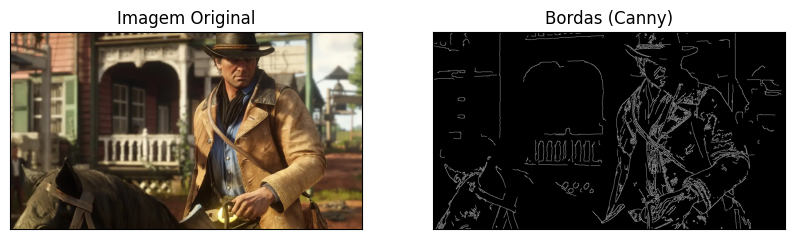

In [6]:
# Aplicando o detector de Canny
edges = cv.Canny(img_rgb, 100, 200)

# Exibindo as imagens
plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(img_rgb, cmap='gray')
plt.title('Imagem Original'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(edges, cmap='gray')
plt.title('Bordas (Canny)'), plt.xticks([]), plt.yticks([])
plt.show()

A parte de detecção de bordas foi finalizada. Consegue notar o por que fazer essa etapa é importante? Caso não, aqui vão algumas aplicações práticas:

- Redução de Dados: As bordas contêm informações essenciais sobre a estrutura de uma imagem, permitindo representar objetos de forma mais compacta.

- Segmentação de Imagens: Ajuda a separar objetos dentro de uma imagem, facilitando o reconhecimento e a análise de diferentes regiões.

- Detecção de Objetos: Muitos algoritmos de visão computacional dependem da extração de bordas para identificar e localizar objetos em imagens.

- Reconhecimento de Padrões: Bordas destacam contornos e formas, facilitando o reconhecimento de padrões em aplicações como reconhecimento facial e OCR (reconhecimento óptico de caracteres).

- Visão Robótica e Navegação: Em robôs e veículos autônomos, a detecção de bordas ajuda na percepção do ambiente e na tomada de decisões baseadas em obstáculos e trajetórias.

E muitas outras aplicações...

### ❗ Atividade - Detecção de Bordas  
Que tal um desafio? A imagem abaixo mostra uma tomografia cerebral com um tumor. A medicina já utiliza modelos preditivos para diagnosticar câncer há algum tempo, mas agora é a sua vez de analisar!

Sua tarefa é aplicar algoritmos de detecção de bordas e avaliar se a identificação do tumor se torna mais evidente. Experimente utilizar tanto o filtro de Sobel quanto o detector de Canny e compare os resultados. Será que a segmentação do tumor fica mais nítida? Inclusive, a imagem original já tem a resposta, indicada por um médico.

O link da imagem pode ser simplesmente colocada nos códigos rodados anteriormenre: https://drive.google.com/file/d/1J19U8kzmxTyTD-TRhwhf3aDf41oxJVyi/view?usp=drive_link

In [7]:
# Coloque seu código aqui!

---

## Detecção de Cantos

Assim como as bordas, os cantos são extremamente importantes no pré-processamento de imagens. Com eles, podemos determinar profundidade, dimensões e localização de certos objetos.

### Detector de Cantos de Harris

O **Detector de Cantos de Harris** é um algoritmo utilizado para identificar pontos de interesse em uma imagem, como cantos ou bordas significativas. Ele se baseia na análise da variação da intensidade dentro de uma pequena janela de pixels.

#### Princípio do Método

Dada uma janela $ W $ centrada em um ponto $ (u, v) $ da imagem $ I $, o método analisa como a intensidade média da janela muda quando deslocada por um pequeno valor $ (x, y) $. Existem três possíveis cenários:

1. **Região de intensidade constante:** O deslocamento em qualquer direção causa pouca ou nenhuma alteração na intensidade média.
2. **Borda:** O deslocamento ao longo da borda gera pouca mudança, mas um deslocamento perpendicular à borda resulta em uma variação significativa.
3. **Canto (ou ponto isolado):** O deslocamento em qualquer direção gera uma grande mudança na intensidade média.

#### Diferença Quadrática Ponderada

A diferença entre a janela original e a janela deslocada é dada por:

$$
S(x, y) = \sum_{u,v} w(u,v) [I(x+u, y+v) - I(u,v)]^2
$$

Aproximando $ I(x+u, y+v) $ pela expansão de Taylor:

$$
I(x+u, y+v) \approx I(u,v) + I_x(u,v) x + I_y(u,v) y
$$

Substituindo na equação de $ S(x,y) $:

$$
S(x, y) \approx \sum_{u,v} w(u,v) [I_x(u,v) x + I_y(u,v) y]^2
$$

De forma matricial:

$$
S(x, y) \approx \begin{bmatrix} x & y \end{bmatrix} A \begin{bmatrix} x \\ y \end{bmatrix}
$$

onde $ A $ é a matriz do tensor de estrutura:

$$
A = \sum_{u,v} w(u,v) \begin{bmatrix} I_x^2 & I_x I_y \\ I_x I_y & I_y^2 \end{bmatrix}
$$

#### Análise dos Autovalores

Os autovalores $ \lambda_1 $ e $ \lambda_2 $ da matriz $ A $ indicam o tipo de região:

1. Se $ \lambda_1 \approx 0 $ e $ \lambda_2 \approx 0 $, a região tem intensidade constante.
2. Se $ \lambda_1 >> \lambda_2 $, ou vice versa, encontramos uma borda.
3. Se $ \lambda_1 $ e $ \lambda_2 $ forem grandes, identificamos um canto.

A equação dos autovalores da matriz $ A $ é dada por:

$$
\lambda = \frac{a_{11} + a_{22} \pm \sqrt{(a_{11} + a_{22})^2 - 4(a_{11} a_{22} - a_{12} a_{21})}}{2}
$$

onde:

- $ a_{11} = \sum I_x^2 $
- $ a_{22} = \sum I_y^2 $
- $ a_{12} = a_{21} = \sum I_x I_y $

Se utilizarmos uma janela gaussiana para $ w(u,v) $, garantimos uma resposta isotrópica (invariante à rotação) ao detector.

![image.png](https://drive.google.com/uc?export=view&id=1Ek-auI6A47qWPTjFrXBRGx1W8BsmCubD)


Vamos a um exemplo:

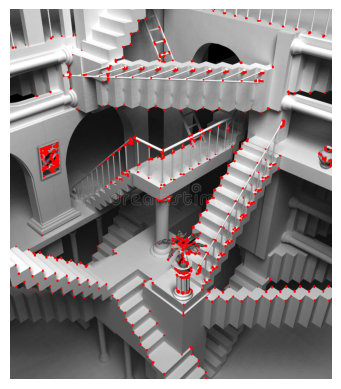

In [8]:
url = 'https://drive.google.com/uc?export=view&id=1L-xl41SqM_X90ZOHxxJ06OM_qk5IBI4X'
response = requests.get(url)
img_arr = np.asarray(bytearray(response.content), dtype=np.uint8)
img = cv.imdecode(img_arr, cv.IMREAD_COLOR)

# Convertendo a imagem para escala de cinza
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Convertendo para tipo float32
gray = np.float32(gray)

# Detecção de cantos usando Harris
dst = cv.cornerHarris(gray, 4, 3, 0.06)

# Dilatação para destacar os cantos
dst = cv.dilate(dst, None)

# Aplicando um limiar para marcar os cantos detectados
img[dst > 0.01 * dst.max()] = [0, 0, 255]

# Exibindo a imagem com cantos detectados usando matplotlib
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.axis('off')  # Desativa os eixos
plt.show()

## Descritores de características

Descritores de características são ferramentas essenciais no processamento de imagens, especialmente para tarefas como reconhecimento de objetos, correspondência de imagens e compreensão de cenas. Esses descritores capturam informações distintas de regiões ou pontos-chave específicos dentro de uma imagem, permitindo uma análise robusta e eficiente. A seguir, vamos ver alguns descritores de características comumente utilizados:

### SIFT
O SIFT é um método amplamente utilizado para detectar e descrever características locais em imagens. Ele identifica pontos-chave na imagem que são invariantes a mudanças de escala, rotação e iluminação. O SIFT funciona identificando primeiro pontos-chave potenciais com base em extremos no espaço de escalas da pirâmide de imagens. Em seguida, ele calcula um descritor para cada ponto-chave, considerando as informações do gradiente local em sua vizinhança. Esses descritores são altamente distintivos e robustos, tornando-os adequados para tarefas como reconhecimento de objetos, combinação de imagens e reconstrução 3D. Pense em um exemplo no qual queremos determinar pontos correspondentes em múltiplas imagens de um mesmo objeto, o método SIFT, portanto, ajudaría-nos a cumprir essa tarefa.

Esse método possui diversos algoritmos embutidos e muitas abordagens, porém há algumas delas que devem ser destacadas:

#### Scale-space peak Selection

Lembre-se dos métodos de detecção de bordas e cantos anteriormente falados. O que acontece se nas imagens nós aumentarmos a dimensão delas? Os cantos e bordas seriam reconhecidos da mesma forma? A resposta é que não, esses são alguns dos problemas em usar apenas uma escala de imagem, o que é razoável, já que isso pode ser analisado até mesmo na natureza, por exemplo ao comparar o tamanho de uma pessoa ao tamanho de uma árvore e depois comparar ao tamanho de um planeta.

Portanto, uma forma de diminuir os problemas relacionados à escala de imagens que algumas transformações são feitas no método SIFT.

![image.png](https://drive.google.com/uc?export=view&id=1GHh1v8Fjd53JX4LUMcpZpxsZpbL8gpnR)

O espaço de escala de uma imagem é uma função L(x,y,σ) que é obtida a partir da convolução de um kernel Gaussiano com a imagem de entrada em diferentes escalas. O espaço de escala é dividido em oitavas e o número de oitavas e escalas depende do tamanho da imagem original. Dessa forma, são geradas várias oitavas da imagem original e cada imagem de uma oitava tem metade do tamanho da anterior.

Dentro de uma oitava, as imagens são progressivamente suavizadas usando o operador de Blurring Gaussiano. Matematicamente, o blurring (desfoque) é a convolução (já vimos a convolução anteriormente) entre o operador Gaussiano e a imagem. O Desfoque Gaussiano possui uma expressão específica que é aplicada a cada pixel e o resultado dessa operação é a imagem suavizada.

O operador de Desfoque Gaussiano é representado por G, enquanto a imagem original é representada por I. As coordenadas x e y determinam a posição de cada pixel e σ é o parâmetro de escala que controla a quantidade de desfoque, sendo que quanto maior o valor de σ, maior será o desfoque na imagem.

$$L(x, y, σ) = G(x, y, σ) * I(x, y)$$

$$G(x, y, σ) = \frac{1}{2πσ²}e^{-\frac{(x²+y²)}{2σ²}}$$

Agora, utilizamos essas imagens suavizadas para gerar um novo conjunto de imagens chamadas de Diferença de Gaussianas (DoG). Essas imagens DoG são essenciais para encontrar pontos-chave na imagem. A Diferença de Gaussianas é calculada como a diferença entre duas versões da imagem suavizadas com diferentes valores de σ, sendo um deles σ e o outro kσ. Esse processo é repetido para diferentes oitavas na Pirâmide Gaussiana. Fazemos essas etapas para que características predominantes (ainda influentes mesmo com desfoque) sejam ressaltadas, enquanto que características genéricas, ruídos, etc. (as diferenças de gaussianas "eliminam" padrões fracos) sejam ignoradas.

![image.png](https://drive.google.com/uc?export=view&id=1Yy4gA2EFS6D5vYO1ooHcJ6Q22qPdYTuU)

Até este momento, foi gerado um espaço de escala e, a partir dele, calculamos a Diferença de Gaussianas, que é então utilizada para obter aproximações do Laplaciano de Gauss, que são invariantes à escala. Para tantp, cada pixel de uma imagem é comparado com seus oito vizinhos diretos, além de ser comparado com nove pixels na escala anterior e nove pixels na escala posterior. Assim, um total de 26 verificações é realizado para determinar se um pixel é um extremo local, o que significa que ele pode ser um ponto-chave. Isso basicamente indica que aquele ponto é melhor representado naquela escala específica. Essa técnica de encontrar máximos já foi utilizada nos métodos de detecção anteriores, você se lembra?

![image.png](https://drive.google.com/uc?export=view&id=1kGDHKNz3RvLWYz8piLkY7lWpF_3qYQHE)

#### Keypoint localization

Basicamente, na etapa anterior, diversos pontos teoricamente relevantes são produzidos, porém nem todos são úteis ou, de fato, importantes. Então, devemos introduzir algo semelhante à detecção de cantos de Harris para eliminar certas features "ruído" checando a intensidade delas nas matrizes resultantes. Para tanto, os valores extremos de pontos vindos da diferença de gaussianas são comparados a um threshold (relevância), normalmente de 0.03, como definido no artigo que foi publicado o SIFT. Se for menor que esse threshold, a feature é, portanto, descartada.

Porém, como o SIFT também percebe bordas, devemos arranjar uma forma que elas também sejam eliminadas, pois as bordas não são características independentes da variância do espaço, já que elas podem mudar de forma conforme é visualizada. Dito isso, uma matriz Hessiana 2x2 é utilizada (segundas derivandas de uma variável na diagonal principal e derivadas parciais de cada variável no resto dos elementos da matriz), a qual permite calcular a curvatura principal da região ao redor do ponto. Essa análise ajuda a eliminar respostas que correspondem a bordas e preservar apenas os pontos-chave mais robustos e representativos da imagem:

![image.png](https://drive.google.com/uc?export=view&id=11uiDavaTm_fGKAAXGJD0qLD-LeEZXpHi)

Para selecionar pontos-chave válidos e eliminar aqueles que não são significativos, duas verificações são realizadas:

- Eliminação de pontos de baixa intensidade: Se a intensidade de um ponto extremo for menor que 0.03, ele é descartado, pois valores muito baixos indicam que o ponto não é suficientemente distinto para ser uma característica robusta.

- Eliminação de bordas espúrias: O método SIFT utiliza a matriz Hessiana para analisar a curvatura da imagem e determinar se um ponto é uma borda ou um canto. Para isso, é calculado um parâmetro r, que é baseado na razão entre os autovalores da matriz Hessiana. Esse parâmetro ajuda a distinguir entre cantos (bons pontos-chave) e bordas (que devem ser eliminadas).

#### Orientation Assignment

Agora que identificamos os pontos-chave verdadeiros, é necessário atribuir uma orientação a cada um deles. Isso se deve ao fato de que, se a imagem for rotacionada, os métodos anteriores de detecção de pontos-chave poderiam selecionar diferentes pontos, embora, na realidade, sejam os mesmos. Ao introduzir uma orientação, garantimos que, independentemente da rotação da imagem, os pontos-chave permanecem consistentes, permitindo sua correta identificação.

Para realizar esse processo, calculamos os gradientes em uma região da imagem, utilizando as derivadas em x e y. Em seguida, analisamos o ângulo do gradiente em cada ponto e o atribuímos a bins específicos. Por exemplo, se o ângulo for de 15 graus, ele será colocado no bin de 10-19 graus. Por fim, criamos um histograma, no qual a quantidade associada a cada bin é proporcional à magnitude do gradiente naquela região.

Após isso, os bins que possuirem mais de 80% em relação ao maior pico serão selecionados para calcular a orientação de um determinado ponto chave.

As imagens a seguir ilustram melhor esse processo.

![image.png](https://drive.google.com/uc?export=view&id=1J0_7hld2kdTNThZrCJIUX0MkxRs4nrS_)


#### Keypoint descriptor

Keypoint descriptor é a próxima etapa após identificar os pontos-chave, onde o objetivo é criar uma representação única e robusta para cada ponto-chave que seja resistente a variações como mudanças de ponto de vista e iluminação.

Para fazer isso, uma janela de 16x16 pixels ao redor de cada ponto-chave é selecionada. Esta janela é dividida em 16 sub-blocos de 4x4 pixels cada. Para cada sub-bloco, é criado um histograma de orientações com 8 bins, que captura a direção dominante do gradiente em cada área da imagem.

No total, ao combinar 4x4 descritores em uma matriz de 16x16 pixels, o descritor de cada ponto-chave tem 128 valores de bin (4x4x8), representando um vetor de características único para esse ponto-chave.

Porém, essa representação inicial possui algumas dependências que precisam ser ajustadas para garantir que o descritor seja realmente robusto:

- Dependência de rotação: Como o vetor de características depende das orientações dos gradientes, a rotação da imagem faz com que todas as orientações também mudem. Para tornar o descritor invariante à rotação, subtrai-se a orientação do ponto-chave de todas as orientações no histograma. Isso faz com que o vetor de características seja relativo à orientação do ponto-chave, tornando-o invariável a rotações.

- Dependência de iluminação: Mudanças na iluminação podem afetar a intensidade dos gradientes, tornando o descritor sensível a variações de iluminação. Para resolver isso, os valores do vetor de características maiores que 0,2 são limitados a 0,2, o que impede que grandes variações de iluminação afetem a descrição do ponto-chave. Após esse ajuste, o vetor de características é normalizado novamente, tornando-o independente de mudanças na iluminação.

![image.png](https://drive.google.com/uc?export=view&id=1sk0QwdE1Fe6OWoXMJ8QQ3nEEt--oeYvW)



#### Implementação SIFT

Vamos, finalmente, colocar a mão na massa! Você verá que o uso de bibliotecas deixa tudo mais fácil.

Vamos começar mostrando os pontos chaves de uma determinada imagem:

![image.png](https://drive.google.com/uc?export=view&id=1uYiGlm1v7z6-gcpziQ5SmzRWBVwr1cpY)

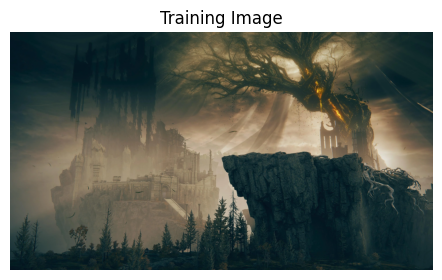

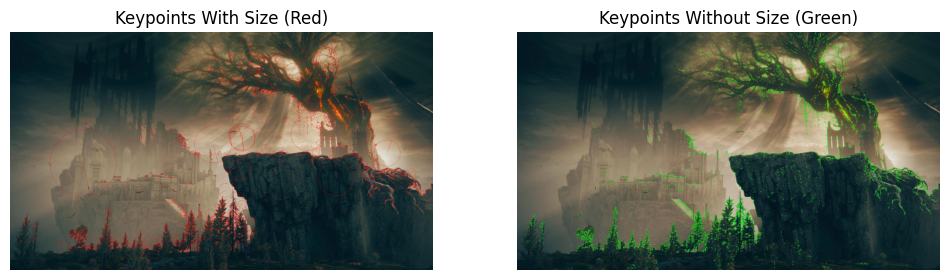

In [9]:
url = "https://drive.google.com/uc?export=view&id=1uYiGlm1v7z6-gcpziQ5SmzRWBVwr1cpY"
response = requests.get(url)
img_array = np.array(bytearray(response.content), dtype=np.uint8)
image = cv.imdecode(img_array, cv.IMREAD_COLOR)  # Carregar a imagem colorida

# Converter a imagem para RGB para exibição correta no Matplotlib
training_image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# Converter para escala de cinza
training_gray = cv.cvtColor(training_image, cv.COLOR_RGB2GRAY)

# Criar o detector SIFT
sift = cv.SIFT_create()

# Detectar keypoints e calcular descritores
train_keypoints, train_descriptor = sift.detectAndCompute(training_gray, None)

# Criar cópias da imagem para desenhar os keypoints
keypoints_with_size = np.copy(training_image)
keypoints_without_size = np.copy(training_image)

cv.drawKeypoints(training_image, train_keypoints, keypoints_without_size,
                 color=(0, 255, 0), flags=0)  # Pequenos pontos verdes

cv.drawKeypoints(training_image, train_keypoints, keypoints_with_size,
                 flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
                 color=(255, 0, 0))  # Keypoints destacados em vermelho

# Exibir imagens de treinamento e teste em um gráfico separado
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Training Image")
plt.imshow(training_image)
plt.axis("off")

# Exibir keypoints detectados em um gráfico separado
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Keypoints With Size (Red)")
plt.imshow(keypoints_with_size)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Keypoints Without Size (Green)")
plt.imshow(keypoints_without_size)
plt.axis("off")
plt.show()

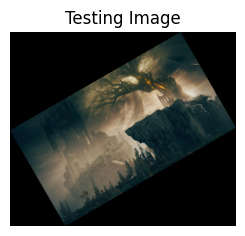

In [10]:
# Criar imagem de teste reduzida e rotacionada (Simulação de Transformações)
test_image = cv.pyrDown(training_image)
test_image = cv.pyrDown(test_image)
num_rows, num_cols = test_image.shape[:2]

rotation_matrix = cv.getRotationMatrix2D((num_cols/2, num_rows/2), 30, 1)

# Garantir que a imagem rotacionada não seja cortada
cos_val = np.abs(rotation_matrix[0, 0])
sin_val = np.abs(rotation_matrix[0, 1])

new_width = int((num_rows * sin_val) + (num_cols * cos_val))
new_height = int((num_rows * cos_val) + (num_cols * sin_val))

# Ajustar a matriz de rotação para a nova dimensão
rotation_matrix[0, 2] += (new_width - num_cols) / 2
rotation_matrix[1, 2] += (new_height - num_rows) / 2


test_image = cv.warpAffine(test_image, rotation_matrix, (new_width, new_height))

test_gray = cv.cvtColor(test_image, cv.COLOR_RGB2GRAY)

test_keypoints, test_descriptor = sift.detectAndCompute(test_gray, None)

plt.subplot(1, 2, 2)
plt.title("Testing Image")
plt.imshow(test_image)
plt.axis("off")
plt.show()

Number of Keypoints Detected In The Training Image: 9670
Number of Keypoints Detected In The Query Image: 1029


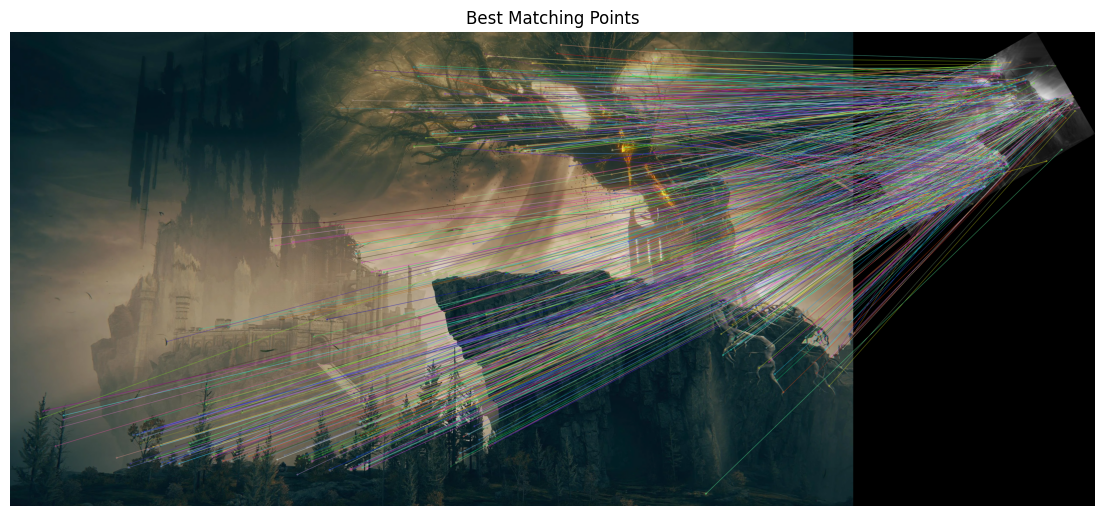


Number of Matching Keypoints Between The Training and Query Images: 808


In [11]:
# Mostrar quantos keypoints foram detectados
print("Number of Keypoints Detected In The Training Image:", len(train_keypoints))
print("Number of Keypoints Detected In The Query Image:", len(test_keypoints))

# Criar um Brute Force Matcher
bf = cv.BFMatcher(cv.NORM_L2, crossCheck=True)

# Fazer o matching entre descritores da imagem de treinamento e teste
matches = bf.match(train_descriptor, test_descriptor)

# Ordenar os matches por distância (menor é melhor)
matches = sorted(matches, key=lambda x: x.distance)

# Desenhar os melhores matches
result = cv.drawMatches(training_image, train_keypoints, test_gray, test_keypoints,
                        matches, None, flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Exibir os melhores pontos de correspondência
plt.figure(figsize=(14, 7))
plt.title("Best Matching Points")
plt.imshow(result)
plt.axis("off")
plt.show()

# Mostrar total de keypoints correspondentes entre as imagens
print("\nNumber of Matching Keypoints Between The Training and Query Images:", len(matches))

#### ❗ Atividade - Testando o SIFT

A essa altura, você já completou o notebook de Data Augmentation. Nesta atividade, você combinará os conhecimentos adquiridos anteriormente com técnicas de detecção de características.

Sua tarefa é gerar uma nova imagem a partir da foto a seguir (link), aplicando uma rotação de 45° e um zoom out de 0,45. Em seguida, você deve identificar os 10 keypoints com as menores distâncias no espaço vetorial dos descritores entre as duas imagens. Você deve fazer com que esses pontos que batem fiquem bem visíveis, com linhas que ligam um ponto a outro mais expessas e com cores fortes. Além disso, cada keypoint deve ser circulado.

Imagem:

![image.png](https://drive.google.com/uc?export=view&id=1_J_LNrBEbBfWI3WdDcxT7W8qqfubq5HX)

In [12]:
# Deixe seu código aqui!

In [13]:
# Deixe seu código aqui!

In [14]:
# Deixe seu código aqui!

### SURF

O método SURF (Speeded Up Robust Features) é um algoritmo rápido e robusto para representação e comparação de imagens com invariância a similaridades locais. Seu principal diferencial é o cálculo rápido de operadores usando filtros de caixa, permitindo aplicações em tempo real, como rastreamento e reconhecimento de objetos.

Ele é basicamente composto de duas macro etapas:

#### Feature Extraction

A diferença principal do SIFT para o SURF é que a matriz hessiana para cada região da imagem (kernel que percorre a imagem) é calculada desde o começo, passando como para essa matriz o Laplaciano da segunda derivada da Gaussiana:

$$
𝓗(x, y, σ) = \begin{bmatrix} L_{xx}(x, y, σ) & L_{xy}(x, y, σ) \\ L_{xy}(x, y, σ) & L_{yy}(x, y, σ) \end{bmatrix}
$$

Mas só que aí há um detalhe: Antes do cálculo da Hessiana, o SURF cria filtros de caixa para justamente aproximar tanto as segundas derivadas, quanto as Gaussianas. Para isso, as caixas de filtros são aplicadas em regiões de uma imagem e dentro dessas caixas, kernels que aproximam a convolução Gaussiana são aplicados:

![image.png](https://drive.google.com/uc?export=view&id=1ZZAC0b4TF2qVw7k4Mu86sOprofQ5Krbn)

![image.png](https://drive.google.com/uc?export=view&id=1QO3EqH0gWIUrJWneDP5auqLylFIdavfM)

O próximo passo é deixar a imagem invariante a escala. Lembra-se da sub amostragem realizada no SIFT? O SURF não precisa criar várias amostras de uma só imagem, mas sim apenas diminuir ou aumentar essas box filters. Então, primeiro começa um filtro pequeno que varre a imagem e ele vai aumentando progressivamente (SIFT à esquerda, SURF à direita):

![image.png](https://drive.google.com/uc?export=view&id=1O5yosdNd8dPJjCOs3ct5k_8aoSxQTtts)

#### Feature Description

A criação do descritor SURF ocorre em duas etapas principais. A primeira consiste em atribuir uma orientação reproduzível aos pontos de interesse, baseada nas informações de uma região circular ao redor do ponto-chave. Para isso, o SURF calcula as respostas de onda de Haar nas direções x e y dentro de uma vizinhança circular com raio 6s ao redor do ponto-chave, onde s é a escala na qual o ponto foi detectado. O passo de amostragem é dependente da escala e é escolhido como s, com as respostas de onda calculadas na escala atual. Em escalas maiores, o tamanho das ondas de Haar é maior, e para agilizar o cálculo, são utilizadas imagens integrais.

Após calcular as respostas de onda de Haar, o próximo passo é somar as respostas verticais e horizontais dentro de uma área de varredura, e então alterar a orientação da varredura, adicionando um valor de π/3, repetindo o processo até que a orientação que produza a maior soma seja encontrada. Essa orientação será a orientação principal usada no descritor de características.

![image.png](https://drive.google.com/uc?export=view&id=157vUsG6zdlyQqgvLgT8ILzFV5F6wjLBO)

Na segunda etapa, o descritor é extraído. Para isso, constrói-se uma região quadrada centrada no ponto-chave e orientada de acordo com a orientação obtida na etapa anterior. O tamanho dessa janela é 20s. Essa região é então dividida em sub-regiões quadradas de 4 × 4. Para cada sub-região, calculam-se algumas características simples em pontos de amostra dispostos regularmente em uma grade 5 × 5. As respostas dx e dy, que são as respostas de onda de Haar nas direções horizontal e vertical (com filtro de tamanho 2s), são calculadas nesses pontos de amostra. Para aumentar a robustez em relação a deformações geométricas e erros de localização, as respostas dx e dy são ponderadas com uma Gaussiana de desvio padrão σ = 3.3s, com centro no ponto-chave. Isso ajuda a garantir que o descritor seja robusto contra pequenas variações na localização e na geometria da imagem.

![image.png](https://drive.google.com/uc?export=view&id=1hmmNzhCJN1321OuINcSrfWrWNB0uNa54)

Para incorporar informações sobre a polaridade das mudanças de intensidade, o SURF também extrai a soma dos valores absolutos das respostas dx e dy, ou seja, ∑|dx| e ∑|dy|. Isso é importante porque a soma dos valores absolutos captura a magnitude das mudanças de intensidade, independentemente da direção do gradiente.

Portanto, para cada sub-região 4×4, o vetor de características é composto por quatro elementos: a soma das respostas dx (∑ dx), a soma das respostas dy (∑ dy), a soma dos valores absolutos de dx (∑|dx|) e a soma dos valores absolutos de dy (∑|dy|). Isso resulta em um vetor de descritor para cada sub-região de 4×4 com 4 dimensões.

Como há 16 sub-regiões no total (4x4) e cada uma tem um vetor de 4 dimensões, o descritor final tem 64 dimensões (16 sub-regiões × 4 entradas por sub-região). Comparando com o SIFT, que utiliza um vetor de 128 dimensões, o SURF tem um vetor de descritor mais compacto, o que contribui para sua maior rapidez de execução.

Infelizmente, o SURF é um método patenteado que não vem como opção gratuita no import do OpenCV. Para usá-lo a biblioteca inteira deve ser instalada e compilada.

### ORB

Oriented FAST and Rotated BRIEF (ORB) é um método de detecção de features que combina alta precisão com desempenho excepcional. Ele apresenta um desempenho comparável ao SIFT e supera o SURF em muitos cenários, mas com a grande vantagem de ser significativamente mais rápido—chegando a ser quase 100 vezes mais eficiente em termos de tempo de processamento.

Assim como outros métodos, o ORB realiza a detecção de pontos-chave, mas utiliza o detector FAST para essa tarefa. Para a extração de descritores, emprega o BRIEF, que é otimizado para garantir robustez contra rotações.

A seguir, exploraremos em mais detalhes como esses componentes funcionam e por que o ORB se destaca entre os principais detectores de features.

#### FAST

Dado um pixel p em uma imagem, o método FAST compara seu brilho com o de 16 pixels vizinhos que estão distribuídos ao redor dele em um pequeno círculo. Esses pixels vizinhos são então classificados em três categorias: aqueles que são mais claros que p, mais escuros que p ou com brilho semelhante a p. Para que p seja considerado um keypoint, pelo menos 8 desses pixels vizinhos precisam ser significativamente mais claros ou mais escuros do que ele.

Os keypoints detectados pelo método FAST fornecem informações sobre a localização das bordas na imagem, pois esses pontos representam regiões onde há mudanças bruscas de intensidade, indicando transições importantes entre diferentes elementos visuais da cena.

![image.png](https://drive.google.com/uc?export=view&id=1mo5YzcCOqb8phiWfHPQSDMAegtkCt3VU)

Para os pontos chave serem invariantes a escala, a mesma pirâmide utilizada no SIFT é aplicada aqui, diminuindo a imagem a oitavas e realizando a detecção dos pontos:

![image.png](https://drive.google.com/uc?export=view&id=10Qhw5pc_c4TR3m48YeOq6RNRtPEjyA0j)

Após localizar os keypoints, é necessário atribuir uma orientação a cada um deles. Essa orientação pode indicar, por exemplo, se o ponto-chave está virado para a esquerda ou para a direita, dependendo de como os níveis de intensidade da imagem variam ao redor desse ponto. Para determinar essa orientação, o ORB utiliza o conceito de centroide de intensidade.

O centroide de intensidade parte do princípio de que a intensidade luminosa de uma borda ou canto não está distribuída de maneira uniforme ao redor do keypoint, mas sim deslocada em relação ao seu centro geométrico. Esse deslocamento pode ser representado como um vetor que aponta da posição do keypoint para o centroide de intensidade. A direção desse vetor, então, define a orientação do keypoint.

![image.png](https://drive.google.com/uc?export=view&id=1bc_w80bIeCDncCX1bIQ2qjGRdQct0cSW)

Para calcular o centroide, o ORB define os momentos da região ao redor do keypoint, que são somas ponderadas dos valores de intensidade em diferentes posições dentro do patch da imagem. A partir desses momentos, podemos determinar a posição exata do centro de massa da região.

![image.png](https://drive.google.com/uc?export=view&id=17h93ZA87zzCRAfDQ2piBuOW9kjMJykq4)

Com o centro de massa encontrado, podemos traçar um vetor que vai da posição original do keypoint até esse centroide. A direção desse vetor representa a orientação do patch e, consequentemente, a orientação do keypoint.

![image.png](https://drive.google.com/uc?export=view&id=1XyOQa7nR6TrlXLlU34NOrA1Ac_AuDz6n)

![image.png](https://drive.google.com/uc?export=view&id=1ArJRLOm4lZMUnZWAyZJB67pdaeG566DN)

Uma vez que essa orientação foi calculada, podemos rotacionar a região ao redor do keypoint para uma rotação canônica (padronizada). Isso permite que o descritor final extraído dessa região seja invariante à rotação, ou seja, mesmo que a imagem seja girada, o descritor produzido pelo ORB continuará representando a mesma característica da imagem de forma consistente.

#### BRIEF

O BRIEF (Binary Robust Independent Elementary Features) é um método que transforma os keypoints detectados pelo FAST em um vetor de características binário, ou seja, um vetor que contém apenas valores 0 e 1. Esse vetor binário é chamado de descritor binário e representa os padrões locais da imagem, permitindo identificar e comparar objetos.

![image.png](https://drive.google.com/uc?export=view&id=1A9GIvlY_i0CU6F01IwKk96yclfpC4V4F)

- Para evitar que o descritor seja sensível a ruídos de alta frequência, a imagem passa primeiro por um filtro Gaussiano.


- BRIEF seleciona pares de pixels aleatórios dentro de uma região ao redor do keypoint. Essa região é chamada de patch, que é um quadrado centrado no keypoint com um tamanho fixo. O primeiro pixel do par é escolhido de uma distribuição Gaussiana centrada no keypoint. O segundo pixel do par é escolhido de uma distribuição Gaussiana centrada no primeiro pixel, mas com um desvio padrão menor. Se o primeiro pixel for mais brilhante que o segundo, o valor correspondente no vetor binário recebe 1. Se for mais escuro, recebe 0.

![image.png](https://drive.google.com/uc?export=view&id=1etHZ1PxIFFoxXZyk5jlxGwtwbbAQLFPY)

- O processo acima é repetido 128 a 512 vezes para cada keypoint, gerando um vetor binário para cada um.

O BRIEF não é invariante à rotação, ou seja, se um objeto rotacionar na imagem, o descritor muda completamente. O ORB (Oriented FAST and Rotated BRIEF) resolve isso usando rBRIEF (Rotation-aware BRIEF):

- Determina a orientação do keypoint com base no centroide de intensidade.

- Usa essa orientação para rotacionar os pares de pixels antes de calcular o descritor.

- Divide os ângulos em incrementos de 12° (2π/30) e usa uma tabela de padrões BRIEF pré-computados para acelerar o processo.

- Com essa adaptação, o ORB mantém a velocidade do BRIEF mas adiciona invariância à rotação, tornando-o mais robusto para diferentes visualizações do mesmo objeto.

Os vetores de binários são justamente a descrição de um keypoint e a região a que ele pertence. Se precisarmos comparar duas keypoints de duas imagens, o vetor de binários deixa isso muito rápido, podendo dizer se é o mesmo ponto chave ou não.

#### Implementação - ORB

Vamos agora utilizar a mesma imagem anterior para realizarmos a detecção de características utilizando o ORB.

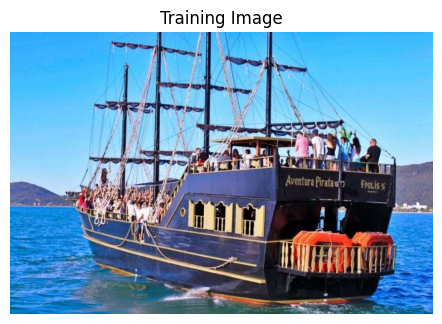

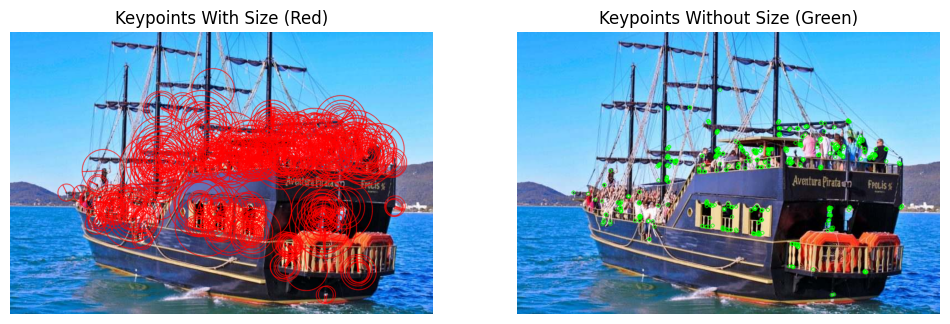

In [15]:
url_orb = "https://drive.google.com/uc?export=view&id=1_J_LNrBEbBfWI3WdDcxT7W8qqfubq5HX"
response_orb = requests.get(url_orb)
img_array_orb = np.array(bytearray(response_orb.content), dtype=np.uint8)
image_orb = cv.imdecode(img_array_orb, cv.IMREAD_COLOR)  # Carregar a imagem colorida

# Converter a imagem para RGB para exibição correta no Matplotlib
training_image_orb = cv.cvtColor(image_orb, cv.COLOR_BGR2RGB)

# Converter para escala de cinza
training_gray_orb = cv.cvtColor(training_image_orb, cv.COLOR_RGB2GRAY)

# Criar o detector ORB
ORB = cv.ORB_create()

# Detectar keypoints e calcular descritores
train_keypoints_orb, train_descriptor_orb = ORB.detectAndCompute(training_gray_orb, None)

# Criar cópias da imagem para desenhar os keypoints
keypoints_with_size_orb = np.copy(training_image_orb)
keypoints_without_size_orb = np.copy(training_image_orb)

cv.drawKeypoints(training_image_orb, train_keypoints_orb, keypoints_without_size_orb,
                 color=(0, 255, 0), flags=0)  # Pequenos pontos verdes

cv.drawKeypoints(training_image_orb, train_keypoints_orb, keypoints_with_size_orb,
                 flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
                 color=(255, 0, 0))  # Keypoints destacados em vermelho

# Exibir imagens de treinamento e teste em um gráfico separado
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Training Image")
plt.imshow(training_image_orb)
plt.axis("off")

# Exibir keypoints detectados em um gráfico separado
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Keypoints With Size (Red)")
plt.imshow(keypoints_with_size_orb)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Keypoints Without Size (Green)")
plt.imshow(keypoints_without_size_orb)
plt.axis("off")
plt.show()

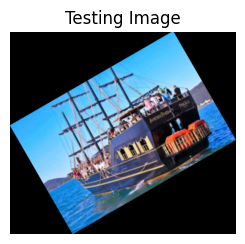

In [16]:
# Criar imagem de teste reduzida e rotacionada (Simulação de Transformações)
test_image_orb = cv.pyrDown(training_image_orb)
num_rows, num_cols = test_image_orb.shape[:2]

rotation_matrix = cv.getRotationMatrix2D((num_cols/2, num_rows/2), 30, 1)

# Garantir que a imagem rotacionada não seja cortada
cos_val = np.abs(rotation_matrix[0, 0])
sin_val = np.abs(rotation_matrix[0, 1])

new_width = int((num_rows * sin_val) + (num_cols * cos_val))
new_height = int((num_rows * cos_val) + (num_cols * sin_val))

# Ajustar a matriz de rotação para a nova dimensão
rotation_matrix[0, 2] += (new_width - num_cols) / 2
rotation_matrix[1, 2] += (new_height - num_rows) / 2


test_image_orb = cv.warpAffine(test_image_orb, rotation_matrix, (new_width, new_height))

test_gray_orb = cv.cvtColor(test_image_orb, cv.COLOR_RGB2GRAY)

test_keypoints_orb, test_descriptor_orb = ORB.detectAndCompute(test_gray_orb, None)

plt.subplot(1, 2, 2)
plt.title("Testing Image")
plt.imshow(test_image_orb)
plt.axis("off")
plt.show()

Number of Keypoints Detected In The Training Image: 500
Number of Keypoints Detected In The Query Image: 500


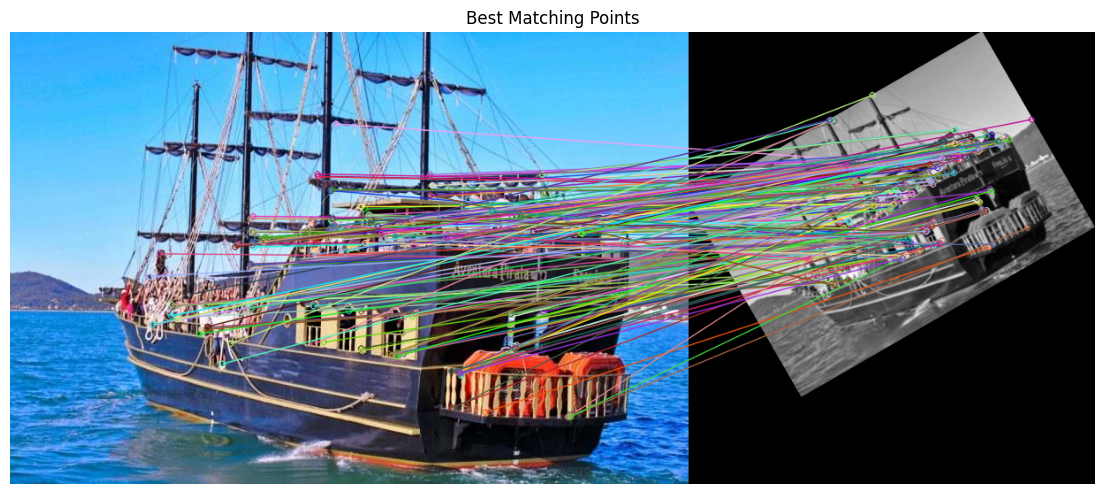


Number of Matching Keypoints Between The Training and Query Images: 209


In [17]:
# Mostrar quantos keypoints foram detectados
print("Number of Keypoints Detected In The Training Image:", len(train_keypoints_orb))
print("Number of Keypoints Detected In The Query Image:", len(test_keypoints_orb))

# Criar um Brute Force Matcher
bf = cv.BFMatcher(cv.NORM_L2, crossCheck=True)

# Fazer o matching entre descritores da imagem de treinamento e teste
matches = bf.match(train_descriptor_orb, test_descriptor_orb)

# Ordenar os matches por distância (menor é melhor)
matches = sorted(matches, key=lambda x: x.distance)

# Desenhar os melhores matches
result = cv.drawMatches(training_image_orb, train_keypoints_orb, test_gray_orb, test_keypoints_orb,
                        matches, None, flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Exibir os melhores pontos de correspondência
plt.figure(figsize=(14, 7))
plt.title("Best Matching Points")
plt.imshow(result)
plt.axis("off")
plt.show()

# Mostrar total de keypoints correspondentes entre as imagens
print("\nNumber of Matching Keypoints Between The Training and Query Images:", len(matches))

#### ❗Atividade - Testando o ORB

Sua tarefa agora é realizar novamente os 10 pontos que melhor batem na imagem do barco acima, rotacionando a imagem de teste em 45 graus e dando um zoom out de 0,45. Porém você deverá comparar o que obteve na atividade do SIFT com o que obterá utilizando o ORB, comparando os pontos que bateram e o tempo de execução.